# Methoden en Technieken -- Blok 2

## Datapunt 2b,

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en
technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model** en
kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen, rekening
houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-
oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld machine learning, deep learning, kennisrepresentatie, computer vision** en natural language
processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch
proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability,
explainability, **model complexity** en resource demand.

Dit is een individuele opdracht. Het is toegestaan met elkaar de opdracht te bespreken, maar iedereen schrijft zijn eigen code en antwoorden. Mocht je code van het internet hebben overgenomen/aangepast, vermeld dan de bron in het commentaar. Het gebruik van generatieve AI (Chat-GPT, etc...) is *alleen* toegestaan bij de voorbereiding op de opdracht. Denk hierbj aan activiteiten zoals brainstormen, of het maken van een plan. Het is niet toegestaan code of tekst van generative AI over te nemen. (Level 2 van de AI Assessment Scale)

Als je gebruik maakt van bronnen om jouw keuzes te verantwoorden willen we bij deze opdracht het volgende zien:
- De bronverwijzing (online link indien beschikbaar)
- De uitspraak die jij doet
- Paragraafnummer uit de bron waar je deze uitspraak op baseert
- Een letterlijke quote uit de bron waar je jouw uitspraak op baseert

(Merk op: dit is veel uitgebreider dan wat er meestal in rapporten verwacht wordt, en is puur bedoeld te controleren of de student correct kan verwijzen.)

Voorbeeld:
> De laatste jaren zijn GANs veel minder populair als generatieve modellen [1] (H17: "(GANs) have gradually fallen out of fashion in recent years and have been all but replaced by diffusion models")
>
> ...
>
> Bronnenlijst:
>
> [1] F. Chollet and M. Watson, Deep Learning in Python, 3rd edition, Manning, 2025. 

https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter17_image-generation.ipynb

base model


## De opdracht

De volgende code laadt de data in. Dit is een gedeeltelijk gelabelde variant van de MNIST dataset

In [ ]:
#| include: false
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import visualkeras

from keras import layers

if torch.cuda.is_available():
    print('Notebook gebruikt windows GPU')
elif torch.mps.is_available():
    print('Notebook gebruikt apple GPU')
else:
    print('Notebook gebruikt CPU')

import matplotlib.pyplot as plt

with open('data_2b_new.pkl', 'rb') as file:
    x_labeled, y_labeled, x_unlabeled = pickle.load(file)

Notebook gebruikt windows GPU


In [24]:
# x_train = (np.expand_dims(x_train, -1).astype("float32"))/ 255
# x_test = (np.expand_dims(x_test, -1).astype("float32")) / 255

In [25]:
# Train/Val/Test split for labeled data (no test labels kept in memory)
from sklearn.model_selection import train_test_split
import numpy as np

RANDOM_SEED = 42

# First split: hold out test set (20%)
x_trainval, x_test, y_trainval, y_test_true = train_test_split(
    x_labeled, y_labeled, test_size=0.20, random_state=RANDOM_SEED, stratify=y_labeled
)

# Second split: from remaining, create validation set (20% of trainval → 16% of total)
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval, test_size=0.20, random_state=RANDOM_SEED, stratify=y_trainval
)

# Print shapes for visibility
print("Split complete:")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val:", x_val.shape, "y_val:", y_val.shape)
print("x_test (held out):", x_test.shape)

# Safety: remove test references to avoid accidental use

del x_test, y_test_true


Split complete:
x_train: (160, 28, 28, 1) y_train: (160,)
x_val: (40, 28, 28, 1) y_val: (40,)
x_test (held out): (50, 28, 28, 1)


De opdracht is om een *semi-supervised* model te trainen dat deze data zo goed mogelijk (rekening houdend met tijd en beschikbare hardware) kan classificeren. De enige voorwaarde is dat dit model gebruik moet maken van een *variational auto encoder* die unsupervised getrained is op deze data. Zie onder andere lessen 11, 12 en 13 van M&T blok 2 voor inspiratie.

Je zult waarschijnlijk meerdere iteraties op beide het *unsupervised* (de VAE) gedeelte en het *supervised* gedeelte van je model doorlopen. Zorg dat deze iteraties duidelijk in je notebook beschreven staan, wis ze niet!

### Deel 1

Voer een data preparatie/verkenning uit, leg kort uit wat je opvalt. Stel op basis hiervan een korte lijst van *requirements* op waar je model aan moet voldoen.

x_train: (160, 28, 28, 1) uint8
y_train: (160,) uint8
x_unlabeled: (69750, 28, 28, 1) float32
x_train pixels -> min: 0.000, max: 1.000, mean: 0.130, std: 0.307
x_unlabeled pixels -> min: 0.000, max: 1.000, mean: 0.131, std: 0.308
Train labels gevonden: [0 1 2 3 4 5 6 7 8 9]
Train per-klasse aantallen: {np.uint8(0): np.int64(19), np.uint8(1): np.int64(19), np.uint8(2): np.int64(12), np.uint8(3): np.int64(13), np.uint8(4): np.int64(13), np.uint8(5): np.int64(24), np.uint8(6): np.int64(13), np.uint8(7): np.int64(15), np.uint8(8): np.int64(14), np.uint8(9): np.int64(18)}


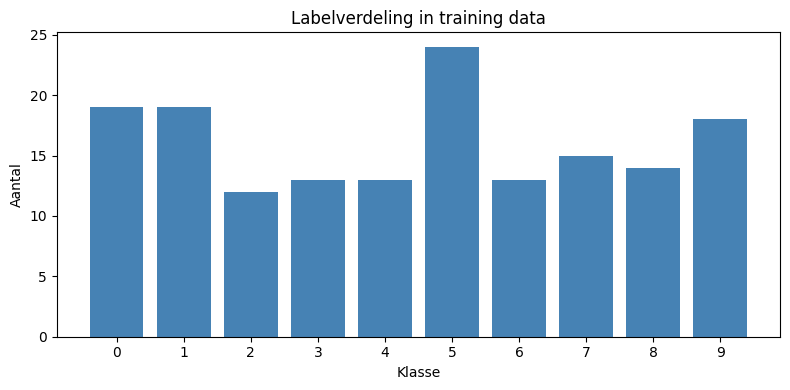

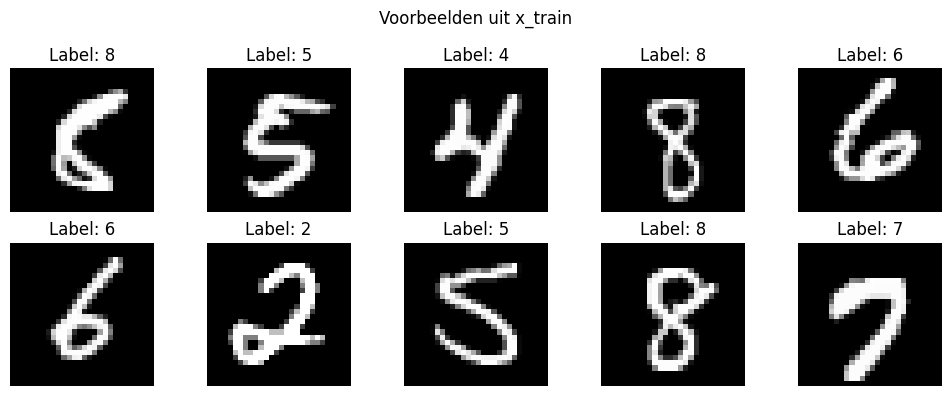

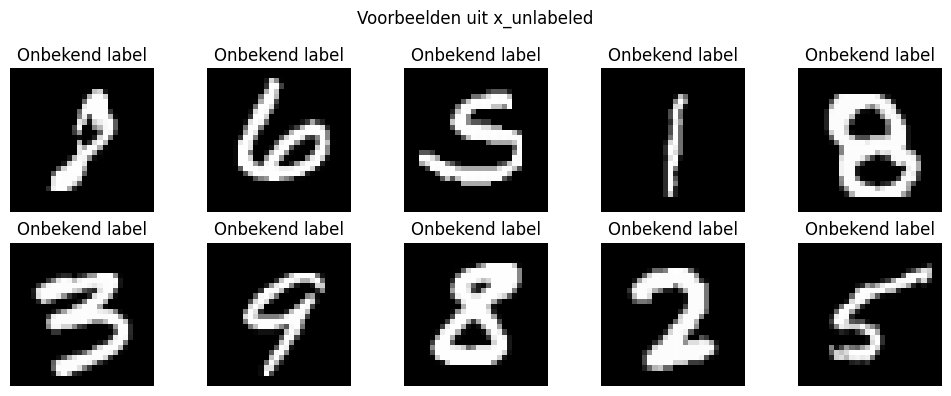

In [26]:
# Data-exploratie voor Datapunt 2b (MNIST variant, deels gelabeld)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basisinformatie (alleen TRAIN + unlabeled; geen VAL/TEST)
print("x_train:", x_train.shape, y_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_unlabeled:", x_unlabeled.shape, x_unlabeled.dtype)

# Stats helper

def describe_pixels(name, arr):
    arr_min = float(np.min(arr))
    arr_max = float(np.max(arr))
    arr_mean = float(np.mean(arr))
    arr_std = float(np.std(arr))
    print(f"{name} pixels -> min: {arr_min:.3f}, max: {arr_max:.3f}, mean: {arr_mean:.3f}, std: {arr_std:.3f}")

# Alleen TRAIN en UNLABELED verkennen (geen VAL/TEST)
describe_pixels("x_train", x_train)
describe_pixels("x_unlabeled", x_unlabeled)

# Labelverdeling (alleen TRAIN)
unique_labels, label_counts = np.unique(y_train, return_counts=True)
print("Train labels gevonden:", unique_labels)
print("Train per-klasse aantallen:", dict(zip(unique_labels, label_counts)))

plt.figure(figsize=(8,4))
plt.bar(unique_labels, label_counts, color="steelblue")
plt.title("Labelverdeling in training data")
plt.xlabel("Klasse")
plt.ylabel("Aantal")
plt.xticks(unique_labels)
plt.tight_layout()
plt.show()

# Enkele voorbeeldafbeeldingen (TRAIN)
n_show = 10
rng = np.random.default_rng(42)
idx_l = rng.choice(len(x_train), size=n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.flat, idx_l):
    img = x_train[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {int(y_train[i])}")
    ax.axis("off")
fig.suptitle("Voorbeelden uit x_train")
plt.tight_layout()
plt.show()

# Enkele voorbeeldafbeeldingen (ONGELABELD)
idx_u = rng.choice(len(x_unlabeled), size=n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.flat, idx_u):
    img = x_unlabeled[i]
    ax.imshow(img, cmap="gray")
    ax.set_title("Onbekend label")
    ax.axis("off")
fig.suptitle("Voorbeelden uit x_unlabeled")
plt.tight_layout()
plt.show()

> Jouw antwoorden hier, voeg gerust cellen toe

## Baseline model

In [27]:
# Baseline supervised CNN classifier (no VAE)
from keras import layers, Model, Input, optimizers

# Build baseline model mirroring encoder structure (Conv → Conv → Flatten → Dense)
baseline_inputs = Input(shape=(28, 28, 1), name="baseline_input")
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(baseline_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu", name="pre_z_dense")(x)  # same layer as in VAE encoder
baseline_outputs = layers.Dense(10, activation="softmax", name="baseline_logits")(x)
baseline_model = Model(baseline_inputs, baseline_outputs, name="baseline_cnn_classifier")

baseline_model.compile(optimizer=optimizers.Adam(),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=12, restore_best_weights=True, min_delta=1e-4, verbose=1
)

baseline_hist = baseline_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1875 - loss: 2.2904 - val_accuracy: 0.2500 - val_loss: 2.2571
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2688 - loss: 2.2461 - val_accuracy: 0.3250 - val_loss: 2.2207
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2812 - loss: 2.2038 - val_accuracy: 0.3500 - val_loss: 2.1747
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3000 - loss: 2.1467 - val_accuracy: 0.3500 - val_loss: 2.1163
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3938 - loss: 2.0785 - val_accuracy: 0.3750 - val_loss: 2.0467
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3812 - loss: 2.0046 - val_accuracy: 0.4250 - val_loss: 1.9724
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3938 - loss: 1.9206 - val_accuracy: 0.4250 - val_loss: 1.8949
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4313 - loss: 1.8267 - val_accuracy: 0.5000 - val_loss:

### Deel 2

Maak een eerste model en verbeter dit via een iteratief en systematisch proces.

## V1

In [28]:
class Sampler(keras.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator()
        self.built = True

    def call(self, z_mean, z_log_var):
        batch_size = keras.ops.shape(z_mean)[0]
        z_size = keras.ops.shape(z_mean)[1]
        epsilon = keras.random.normal((batch_size, z_size), seed=self.seed_generator)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampler()
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        return self.encoder(inputs)

    def compute_loss(self, x, y, y_pred, sample_weight=None, training=True):
        z_mean, z_log_var = y_pred
        z = self.sampler(z_mean, z_log_var)
        reconstruction = self.decoder(z)

        reconstruction_loss = keras.ops.mean(
            keras.ops.sum(keras.ops.binary_crossentropy(x, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
        total_loss = reconstruction_loss + keras.ops.mean(kl_loss)

        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return total_loss

In [29]:
latent_dim = 64

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


In [30]:
# encoder.summary()

# for layer in encoder.layers:
#     layer.output_shape = layer.output.shape
# visualkeras.layered_view(encoder, scale_z=0.03, legend=True)

In [31]:
# decoder.summary()

# for layer in decoder.layers:
#     layer.output_shape = layer.output.shape
# visualkeras.layered_view(decoder, scale_z = 0.03, legend=True)

In [32]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=12, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/200
  6/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - kl_loss: 0.0019 - loss: 536.1559 - reconstruction_loss: 536.1539    

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - kl_loss: 1.5413 - loss: 183.0605 - reconstruction_loss: 181.4520 - val_kl_loss: 2.7694 - val_loss: 126.1935 - val_reconstruction_loss: 123.4100
Epoch 2/200
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - kl_loss: 2.6303 - loss: 115.8131 - reconstruction_loss: 113.1812 - val_kl_loss: 2.5585 - val_loss: 110.4388 - val_reconstruction_loss: 107.8711
Epoch 3/200
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - kl_loss: 2.5260 - loss: 107.6799 - reconstruction_loss: 105.1509 - val_kl_loss: 2.5276 - val_loss: 105.1259 - val_reconstruction_loss: 102.5792
Epoch 4/200
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - kl_loss: 2.4958 - loss: 103.8792 - reconstruction_loss: 101.3790 - val_kl_loss: 2.5082 - val_loss: 102.5847 - val_reconstruction_loss: 100.0507
Epoch 5/200
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - kl_loss: 2.4720 - loss: 101.5740 - reconstruction_loss: 99.1051 - val_kl_loss: 2.4985 - val_loss: 100.6524 - val_reconstruction_loss: 98.1214
Epoch 6/2

In [33]:
import os
os.makedirs('models', exist_ok=True)

vae.save_weights('models/vae1.weights.h5')

with open('models/vae1hist.pkl', 'wb') as file:
    pickle.dump(hist.history, file)

vae.load_weights('models/vae1.weights.h5')

with open('models/vae1hist.pkl', 'rb') as file:
    hist = pickle.load(file)

In [34]:
vae.summary()

Model: "vae_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 64), (None,    │        71,184 │
│                                 │ 64))                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28, 1)      │       110,033 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sampler_1 (Sampler)             │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,653 (2.07 MB)

 Trainable params: 181,217 (707.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 362,436 (1.38 MB)

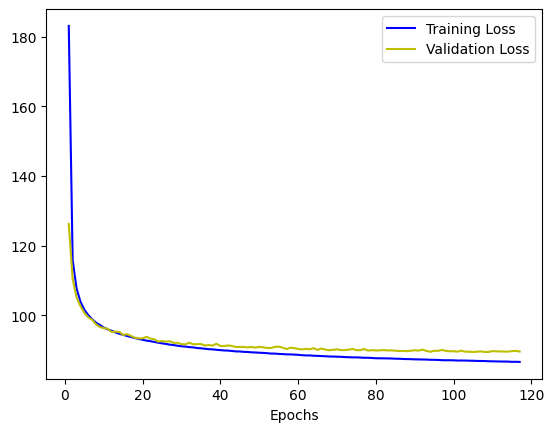

In [35]:
epochs = range(1, len(hist['loss'])+1)
plt.plot(epochs, 'loss', 'b-', data = hist, label = 'Training Loss')
plt.plot(epochs, 'val_loss', 'y-', data = hist, label = 'Validation Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [36]:
# Jouw code hier, voeg gerust cellen toe

> Jouw antwoorden hier, voeg gerust cellen toe

### Deel 3

Evalueer je model.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


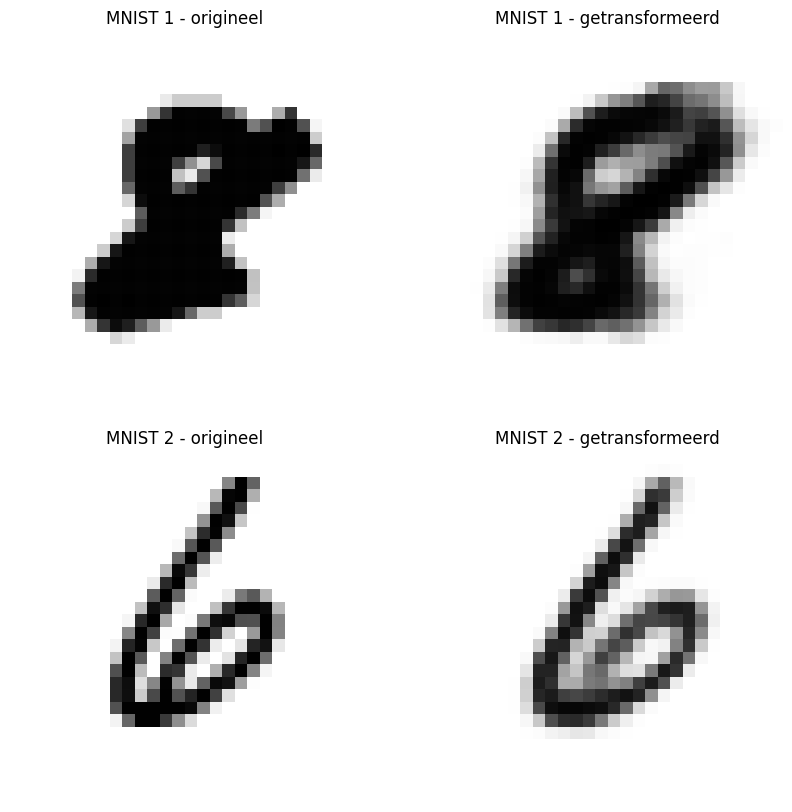

In [37]:
# Preview reconstruction using UNLABELED validation slice (no labeled data involved)
latent, _ = vae.encoder.predict(x_train)
xnew = vae.decoder.predict(latent)

plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
plt.imshow(1-x_train[1].reshape(28,28), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 1 - origineel')
plt.subplot(2,2,2)
plt.imshow(1-xnew[1,:,:,0], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 1 - getransformeerd')
plt.subplot(2,2,3)
plt.imshow(1-x_train[2].reshape(28,28), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 2 - origineel')
plt.subplot(2,2,4)
plt.imshow(1-xnew[2,:,:,0], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 2 - getransformeerd')
plt.show()

In [38]:
# Jouw code hier, voeg gerust cellen toe

> Jouw antwoorden hier, voeg gerust cellen toe

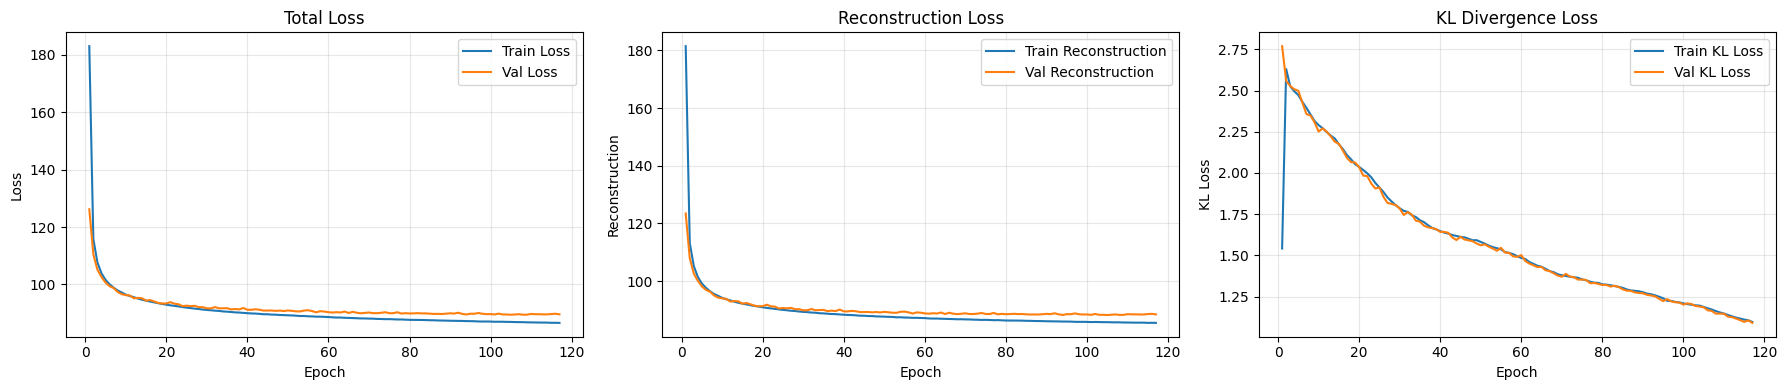

In [39]:
# Expanded training metrics visualization
import matplotlib.pyplot as plt

# Resolve history dict from `hist` (History object or dict-like)
if 'hist' in globals():
    history_dict = getattr(hist, 'history', hist)
else:
    raise NameError("Variable 'hist' not found. Ensure you assigned the result of model.fit(...) to 'hist'.")

# Determine available keys
keys = set(history_dict.keys())

# Build epochs based on 'loss' if present, else any available metric length
ref_key = 'loss' if 'loss' in keys else next(iter(keys))
num_epochs = len(history_dict[ref_key])
epochs = range(1, num_epochs + 1)

# Helper to plot a pair of train/val metrics if present
def plot_pair(ax, train_key, val_key, title, ylabel):
    has_train = train_key in keys
    has_val = val_key in keys
    if not (has_train or has_val):
        ax.set_visible(False)
        return
    if has_train:
        ax.plot(epochs, history_dict[train_key], label=f"Train {ylabel}")
    if has_val:
        ax.plot(epochs, history_dict[val_key], label=f"Val {ylabel}")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) Total loss
plot_pair(
    axes[0],
    'loss',
    'val_loss',
    title='Total Loss',
    ylabel='Loss'
)

# 2) Reconstruction loss
plot_pair(
    axes[1],
    'reconstruction_loss',
    'val_reconstruction_loss',
    title='Reconstruction Loss',
    ylabel='Reconstruction'
)

# 3) KL loss
plot_pair(
    axes[2],
    'kl_loss',
    'val_kl_loss',
    title='KL Divergence Loss',
    ylabel='KL Loss'
)

plt.tight_layout()
plt.show()

In [40]:
# Reuse trained VAE encoder: load weights (if saved), then freeze
import os

# Load top-trained VAE weights if available
weights_path = 'models/vae1.weights.h5'
if os.path.exists(weights_path):
    vae.load_weights(weights_path)
    print(f"Loaded VAE weights from: {weights_path}")
else:
    print("Warning: VAE weights file not found; using current in-memory weights.")

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

# Keep a reference if needed later
vae_encoder = vae.encoder


Loaded VAE weights from: models/vae1.weights.h5


In [ ]:
# VAE-based classifier (semi-supervised): freeze encoder, use z_mean features
from keras import layers, Model, Input, optimizers

# Freeze all encoder layers (no fine-tuning)
vae.encoder.trainable = False

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)
cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0938 - loss: 2.8525 - val_accuracy: 0.0500 - val_loss: 2.8554
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0938 - loss: 2.8242 - val_accuracy: 0.0500 - val_loss: 2.8276
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0938 - loss: 2.7971 - val_accuracy: 0.0500 - val_loss: 2.8008
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0938 - loss: 2.7696 - val_accuracy: 0.0500 - val_loss: 2.7747
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1000 - loss: 2.7437 - val_accuracy: 0.0750 - val_loss: 2.7489
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1000 - loss: 2.7174 - val_accuracy: 0.0750 - val_loss: 2.7235
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1063 - loss: 2.6921 - val_accuracy: 0.0750 - val_loss: 2.6982
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1125 - loss: 2.6663 - val_accuracy: 0.0750 - val_loss: